<a href="https://colab.research.google.com/github/KATHAN-VYAS/LLMguard/blob/main/prompt_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
# Loading pre trained model
print("Loading Sentence Transformer model...")
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading Sentence Transformer model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Encoding all prompts to embeddings vectors
print("Generating embeddings for all prompts...")
df = pd.read_csv(
    'MPDD.csv',
    engine='python',
    quotechar='"'
)


X_embeddings = model.encode(df['Prompt'].tolist(), show_progress_bar=True)

Generating embeddings for all prompts...


Batches:   0%|          | 0/1227 [00:00<?, ?it/s]

In [ ]:

# Convert to numpy array (if not already)
X_embeddings = np.array(X_embeddings)

# Save embeddings
np.save("prompt_embeddings.npy", X_embeddings)

print("✅ Embeddings saved to prompt_embeddings.npy")

✅ Embeddings saved to prompt_embeddings.npy


In [ ]:

# Convert to numpy array (if not already)
X_embeddings = np.array(X_embeddings)

# Save embeddings
np.save("prompt_embeddings.npy", X_embeddings)

print("✅ Embeddings saved to prompt_embeddings.npy")

✅ Embeddings saved to prompt_embeddings.npy


In [ ]:
print("Shape of embeddings:", X_embeddings.shape) #(number of prompts, embedding dimension)

Shape of embeddings: (39234, 384)


In [ ]:
## to load the saved embeddings


import numpy as np

# Load embeddings
X_embeddings = np.load("prompt_embeddings.npy")

df = pd.read_csv(
    'MPDD.csv',
    engine='python',
    quotechar='"'
)

print("Embeddings loaded successfully!")
print("Shape:", X_embeddings.shape)


Embeddings loaded successfully!
Shape: (39234, 384)


In [ ]:
y = df['isMalicious']
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y, test_size=0.2, random_state=42, stratify=y
)

Training and comparing classifiers...

--- Training Logistic Regression ---
✅ Training time: 0.77 sec
✅ Accuracy: 0.9327

--- Training Support Vector Machine ---
✅ Training time: 362.14 sec
✅ Accuracy: 0.9395

--- Training XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [11:31:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Training time: 19.39 sec
✅ Accuracy: 0.9511

--- Model Performance Comparison ---
                        accuracy  training_time
XGBoost                 0.951064      19.388449
Support Vector Machine  0.939467     362.143568
Logistic Regression     0.932713       0.766824

💾 Best model saved as: best_model_xgboost.pkl

--- Evaluation of Best Model: XGBoost ---

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      3924
           1       0.98      0.92      0.95      3923

    accuracy                           0.95      7847
   macro avg       0.95      0.95      0.95      7847
weighted avg       0.95      0.95      0.95      7847



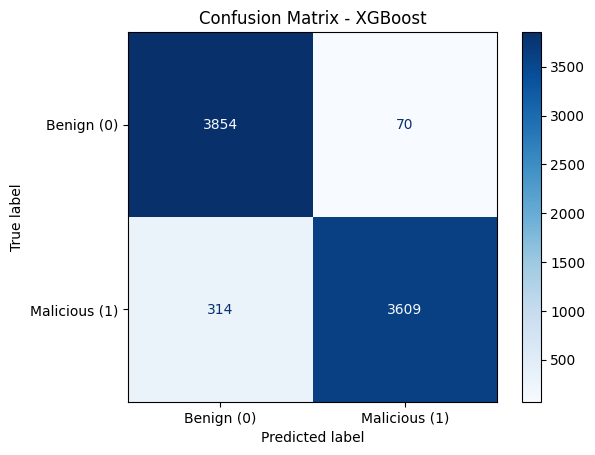

In [ ]:
print("Training and comparing classifiers...")

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import time
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Define classifiers to compare
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Support Vector Machine": SVC(kernel="linear", probability=True, random_state=42),

    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
models = {}

# Train and evaluate each classifier
for name, clf in classifiers.items():
    print(f"\n--- Training {name} ---")
    start_time = time.time()
    clf.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'training_time': train_time
    }
    models[name] = clf

    print(f"✅ Training time: {train_time:.2f} sec")
    print(f"✅ Accuracy: {accuracy:.4f}")

# Summary table
summary_df = pd.DataFrame(results).T
summary_df = summary_df.sort_values(by='accuracy', ascending=False)

print("\n--- Model Performance Comparison ---")
print(summary_df)

# Identify best model
best_name = summary_df.index[0]
best_clf = models[best_name]
best_filename = f"best_model_{best_name.replace(' ', '_').lower()}.pkl"

# Save best model
joblib.dump(best_clf, best_filename)
print(f"\n💾 Best model saved as: {best_filename}")

# Evaluate best model
print(f"\n--- Evaluation of Best Model: {best_name} ---")
y_pred_best = best_clf.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign (0)", "Malicious (1)"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()


In [ ]:
import shap

def predict_proba_for_shap(text_prompts):
    # text to embeddings
    embeddings = model.encode(text_prompts, show_progress_bar=False)
    # prediction
    return clf.predict_proba(embeddings)

#  Create a SHAP Explainer for text

masker = shap.maskers.Text(r"\W+") # Tokenize by any non-word character (spaces, punctuation)
explainer = shap.Explainer(predict_proba_for_shap, masker, output_names=["Benign", "Malicious"])

#  Explain a few examples ---

prompts_to_explain =  df['Prompt'][:5].tolist() # Explain the first 5 prompts

print("\n--- Generating SHAP Explanations ---")
shap_values = explainer(prompts_to_explain)

# --- 5. Visualize the explanations ---
# This plot will show the words in red/blue based on their contribution
print("Displaying explanation for the first prompt...")
shap.plots.text(shap_values[0, :, "Malicious"])

print("\nDisplaying explanation for the second prompt...")
shap.plots.text(shap_values[1, :, "Malicious"])


--- Generating SHAP Explanations ---
Displaying explanation for the first prompt...



Displaying explanation for the second prompt...
